<a href="https://colab.research.google.com/github/Jidnya28/forensic-case-anomaly-detection-system/blob/main/Forensic_Case_Anomaly_Detection_System_model_building_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project is a data science-based anomaly detection system designed to identify suspicious patterns in forensic case data.It analyzes structured case records, detects delays, inconsistencies, and unusual patterns using machine learning models, and presents insights through an interactive dashboard.


👉 The goal is to assist investigators by highlighting high-risk cases early, reducing delays and human error in the justice process.


**Data Loading**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [ ]:
df = pd.read_csv("forensic_cases_dataset.csv")
df

,case_id,incident_date,pm_date,fir_date,victim_age,victim_gender,district,officer_id,narrative,tampered_flag,modifications
0,0,2022-04-13 00:00:00,2022-04-20 12:00:00,2022-05-11 00:00:00,61,Male,Delhi,120,missing document,0,7
1,1,2023-09-07 00:00:00,2023-09-12 02:00:00,2023-09-25 00:00:00,24,Female,Mumbai,102,delay in report,0,7
2,2,2023-10-24 00:00:00,2023-10-26 05:00:00,2023-10-25 00:00:00,2,Male,Pune,163,Normal case with no major issues,0,5
3,3,2024-08-13 00:00:00,2024-08-13 21:00:00,2024-08-13 00:00:00,49,Male,Delhi,190,Normal case with no major issues,0,5
4,4,2022-02-28 00:00:00,2022-03-07 02:00:00,2022-03-27 00:00:00,55,Female,Pune,163,suspicious activity,1,2
...,...,...,...,...,...,...,...,...,...,...,...
1995,1995,2023-08-14 00:00:00,2023-08-20 22:00:00,2023-09-03 00:00:00,70,Female,Chennai,132,suspicious activity,0,7
1996,1996,2024-02-13 00:00:00,2024-02-18 06:00:00,2024-02-19 00:00:00,8,Male,Delhi,176,tampered evidence,0,4
1997,1997,2023-02-01 00:00:00,2023-02-02 16:00:00,2023-02-11 00:00:00,57,Female,Chennai,182,Normal case with no major issues,0,1
1998,1998,2024-07-22 00:00:00,2024-07-23 08:00:00,2024-08-12 00:00:00,25,Male,Kolkata,191,delay in report,0,6


In [ ]:
print(df.head())

   case_id        incident_date              pm_date             fir_date  \
0        0  2022-04-13 00:00:00  2022-04-20 12:00:00  2022-05-11 00:00:00   
1        1  2023-09-07 00:00:00  2023-09-12 02:00:00  2023-09-25 00:00:00   
2        2  2023-10-24 00:00:00  2023-10-26 05:00:00  2023-10-25 00:00:00   
3        3  2024-08-13 00:00:00  2024-08-13 21:00:00  2024-08-13 00:00:00   
4        4  2022-02-28 00:00:00  2022-03-07 02:00:00  2022-03-27 00:00:00   

   victim_age victim_gender district  officer_id  \
0          61          Male    Delhi         120   
1          24        Female   Mumbai         102   
2           2          Male     Pune         163   
3          49          Male    Delhi         190   
4          55        Female     Pune         163   

                          narrative  tampered_flag  modifications  
0                  missing document              0              7  
1                   delay in report              0              7  
2  Normal case with 

In [ ]:
print(df.shape)

(2000, 11)


**EDA**

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   case_id        2000 non-null   int64 
 1   incident_date  2000 non-null   object
 2   pm_date        2000 non-null   object
 3   fir_date       2000 non-null   object
 4   victim_age     2000 non-null   int64 
 5   victim_gender  2000 non-null   object
 6   district       2000 non-null   object
 7   officer_id     2000 non-null   int64 
 8   narrative      2000 non-null   object
 9   tampered_flag  2000 non-null   int64 
 10  modifications  2000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 172.0+ KB
None


In [ ]:
print(df.describe())


           case_id   victim_age   officer_id  tampered_flag  modifications
count  2000.000000  2000.000000  2000.000000    2000.000000    2000.000000
mean    999.500000    40.998500   150.246500       0.156000       4.576000
std     577.494589    22.934243    28.428715       0.362946       2.925834
min       0.000000     1.000000   100.000000       0.000000       0.000000
25%     499.750000    21.000000   126.000000       0.000000       2.000000
50%     999.500000    42.000000   150.000000       0.000000       5.000000
75%    1499.250000    61.000000   175.000000       0.000000       7.000000
max    1999.000000    79.000000   199.000000       1.000000       9.000000


In [ ]:
print(df.isnull().sum())

case_id          0
incident_date    0
pm_date          0
fir_date         0
victim_age       0
victim_gender    0
district         0
officer_id       0
narrative        0
tampered_flag    0
modifications    0
dtype: int64


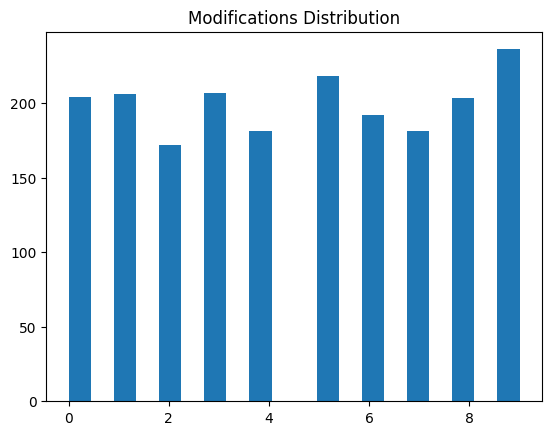

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(df['modifications'], bins=20)
plt.title("Modifications Distribution")
plt.show()

The number of record modifications is distributed fairly evenly across cases

Slightly higher values are seen in cases with 5 to 9 modifications, indicating frequent updates

Frequent modifications may suggest repeated corrections, investigation changes, or possible tampering

Low modification cases (0–2) are more likely to represent stable and normal records

In [ ]:
df['incident_date'] = pd.to_datetime(df['incident_date'])
df['pm_date'] = pd.to_datetime(df['pm_date'])
df['fir_date'] = pd.to_datetime(df['fir_date'])

In [ ]:
# Time gaps
df['pm_gap_hours'] = (df['pm_date'] - df['incident_date']).dt.total_seconds()/3600
df['fir_gap_days'] = (df['fir_date'] - df['incident_date']).dt.days


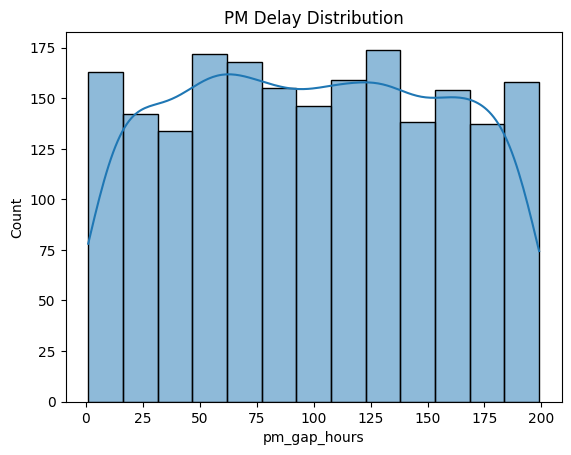

In [ ]:
plt.figure()
sns.histplot(df['pm_gap_hours'], kde=True)
plt.title("PM Delay Distribution")
plt.show()

The post-mortem delay is spread across a wide range from 0 to 200 hours

Most cases are concentrated in the mid-range, showing moderate delays are common

Cases with very high PM delay indicate possible investigation delays or reporting issues

The fairly uniform distribution suggests delays occur across multiple cases, not just a few outliers

In [ ]:
keywords = ['delay','missing','tampered','late','suspicious']

df['keyword_score'] = df['narrative'].astype(str).apply(
    lambda x: sum(k in x.lower() for k in keywords)
)

In [ ]:
df['severity_score'] = (
    0.4*(df['pm_gap_hours']/df['pm_gap_hours'].max()) +
    0.3*(df['fir_gap_days']/df['fir_gap_days'].max()) +
    0.2*df['keyword_score'] +
    0.1*df['modifications']
)

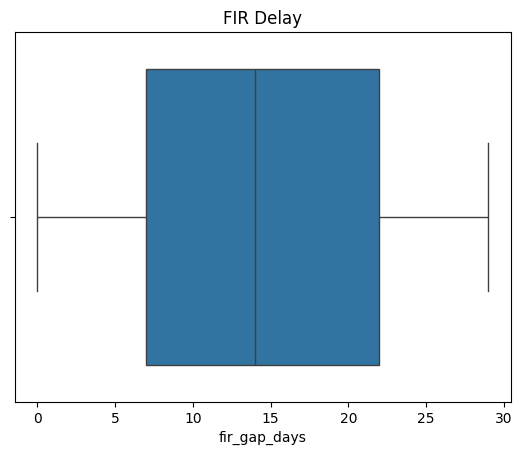

In [ ]:
plt.figure()
sns.boxplot(x=df['fir_gap_days'])
plt.title("FIR Delay")
plt.show()

The median FIR delay is around 14–15 days, showing moderate reporting delay in most cases

Most cases fall between approximately 7 to 22 days, which is the normal range (IQR)

Some cases have delays close to 30 days, which may indicate late reporting or investigation issues

No major extreme outliers are visible, meaning delays are spread fairly consistently across cases

In [ ]:
df['victim_gender'] = df['victim_gender'].factorize()[0]
df['district'] = df['district'].factorize()[0]
df['officer_id'] = df['officer_id'].factorize()[0]

In [ ]:
df['label'] = (
    (df['pm_gap_hours'] > 100) |
    (df['tampered_flag'] == 1) |
    (df['keyword_score'] > 1)
).astype(int)

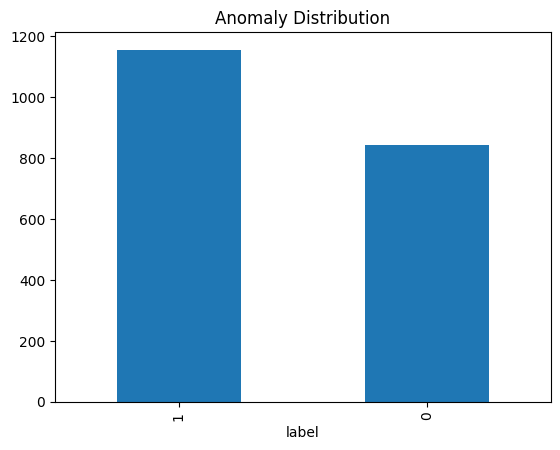

In [ ]:
plt.figure()
df['label'].value_counts().plot(kind='bar')
plt.title("Anomaly Distribution")
plt.show()

Label 1 (Suspicious Cases) count is higher than Label 0 (Normal Cases).

This indicates that a large number of cases show potential delays, tampering, or suspicious patterns

The dataset is slightly imbalanced toward anomaly cases, which helps supervised models learn anomaly patterns better

It confirms that forensic irregularities are significant enough to require early detection systems

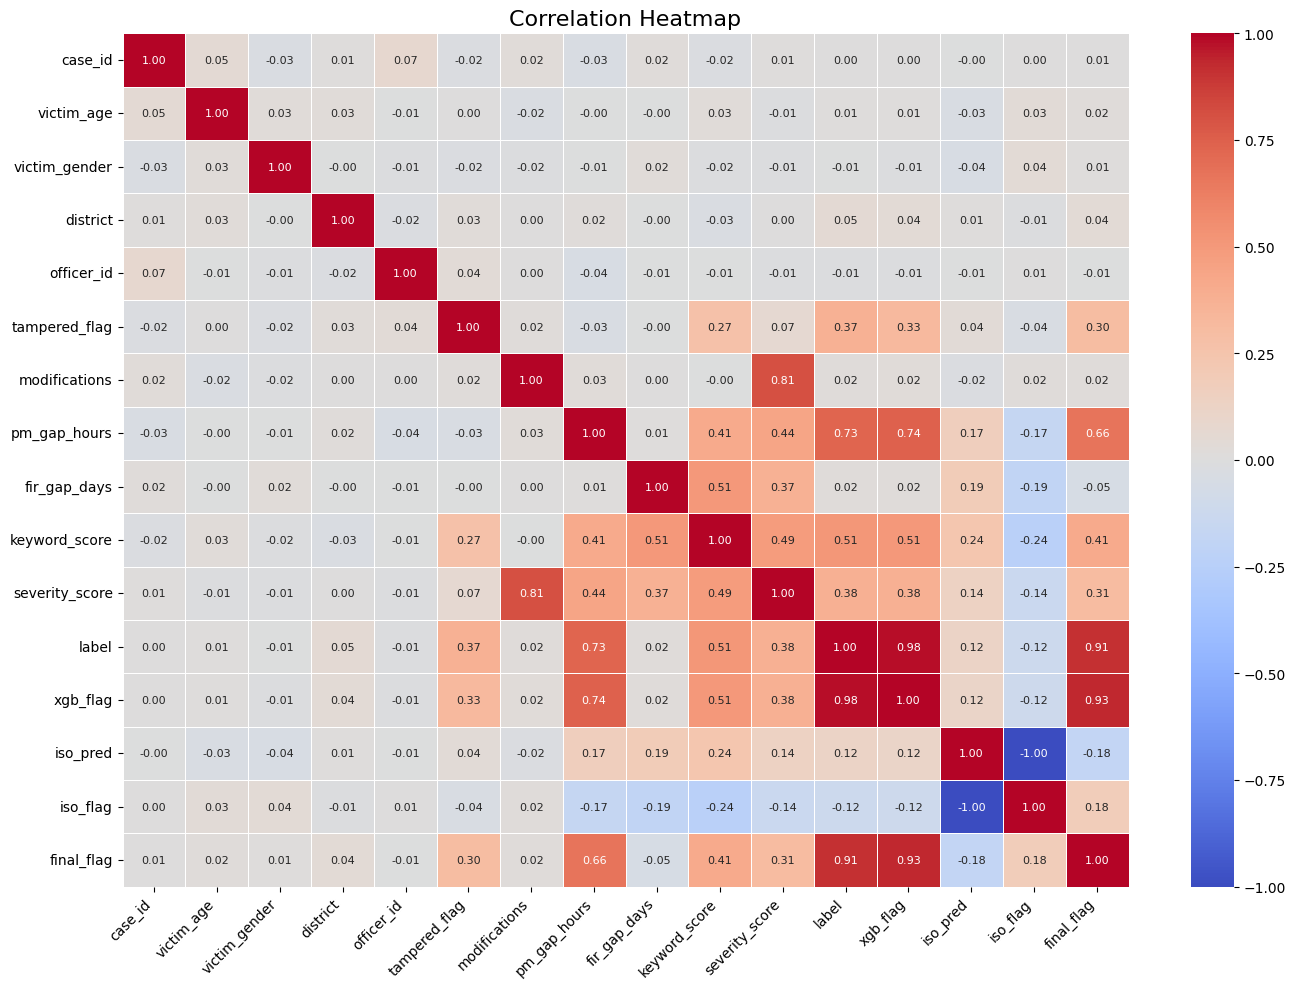

In [ ]:
plt.figure(figsize=(14,10))  # Bigger size

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",               # 2 decimal places
    cmap='coolwarm',
    annot_kws={"size": 8},   # Smaller text
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

From the correlation heatmap, we observed that time delays (especially post-mortem delay) and textual anomaly signals are the strongest predictors of suspicious cases. The XGBoost model shows very high alignment with the target variable, while Isolation Forest captures additional unknown anomalies. This validates the hybrid modeling approach.

MACHINE LEARNING

In [ ]:
features = ['pm_gap_hours','fir_gap_days','keyword_score','severity_score','modifications']
X = df[features]
y = df['label']

Train-test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Logistic Regression ( Baseline)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       147
           1       0.96      0.91      0.93       253

    accuracy                           0.92       400
   macro avg       0.91      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400

[[138   9]
 [ 23 230]]


Simple baseline ,
 Assumes linear relationship → not ideal

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       147
           1       0.99      0.94      0.97       253

    accuracy                           0.96       400
   macro avg       0.95      0.96      0.95       400
weighted avg       0.96      0.96      0.96       400

[[144   3]
 [ 14 239]]


Handles non-linearity
 , Better than LR

XGBoost Model

In [ ]:
import warnings
warnings.filterwarnings('ignore')

!pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.2 MB/s eta 0:00:00
XGBoost
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       147
           1       0.98      0.94      0.96       253

    accuracy                           0.95       400
   macro avg       0.95      0.96      0.95       400
weighted avg       0.96      0.95      0.96       400

[[143   4]
 [ 14 239]]


In [ ]:
df['xgb_flag'] = xgb.predict(df[features])

Boosting → reduces bias + variance
, Best performance → final supervised model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.9200   0.962343  0.909091  0.934959
1        Random Forest    0.9575   0.987603  0.944664  0.965657
2              XGBoost    0.9550   0.983539  0.944664  0.963710


ISOLATION FOREST (UNSUPERVISED)

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
df['iso_pred'] = iso.fit_predict(X)



In [ ]:
# Isolation Forest
df['iso_flag'] = df['iso_pred'].apply(lambda x: 1 if x == -1 else 0)

Works without labels,  Detects unknown anomalies

Hybrid Model

In [ ]:
df['xgb_flag'] = xgb.predict(X)

In [ ]:
df['final_flag'] = ((df['xgb_flag'] == 1) | (df['iso_flag'] == 1)).astype(int)

Hybrid approach reduces false negatives.

In [ ]:
total_cases = len(df)
suspicious_cases = df['final_flag'].sum()
avg_severity = round(df['severity_score'].mean(), 2)
avg_delay = round(df['pm_gap_hours'].mean(), 2)
max_delay = round(df['pm_gap_hours'].max(), 2)

print("Total Cases:", total_cases)
print("Suspicious Cases:", suspicious_cases)
print("Avg Severity:", avg_severity)
print("Avg Delay:", avg_delay)
print("Max Delay:", max_delay)

Total Cases: 2000
Suspicious Cases: 1212
Avg Severity: 0.95
Avg Delay: 99.42
Max Delay: 199.0


In [ ]:
import joblib

joblib.dump(xgb, "xgb_model.pkl")
joblib.dump(iso, "iso_model.pkl")

print("✅ Models saved successfully")

✅ Models saved successfully
